# Insurance Cost Prediction Machine Learnig Pipeline

<h3><b>Learning Task:</b> Build a regression model to predict insurance cost</h3>
<h3><b>Target Variable:</b> 'expenses'</h3>
<h3><b>Peformance Measures:</b> MAE, RMSE and R-Squared error</h3>
<h3><b>Candidate Models:</b> Ridge, Lasso and Linear regression</h3>

**Author:** Harnoor Aulakh

## Introduction

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./insurance.csv')       # For training and validation purposes 

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


## Exploratory Data Analysis

### Basic EDA

In [17]:
df.shape

(1338, 7)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [19]:
print("Data Set Missing or Duplicate Rows")
print("")
print("\tDuplicate Rows:", df.duplicated().sum())
print("\tMissing Values:", df.isnull().sum().sum())
print("")

Data Set Missing or Duplicate Rows

	Duplicate Rows: 1
	Missing Values: 0



In [20]:
# Remove duplicate rows
initial_rows = df.shape[0]

df = df.drop_duplicates().reset_index(drop=True)

removed_rows = initial_rows - df.shape[0]

print("Duplicate Handling Summary")
print("")
print("\tRows before removing duplicates:", initial_rows)
print("\tRows after removing duplicates:", df.shape[0])
print("\tDuplicate rows removed:", removed_rows)
print("\tRemaining duplicate rows:", df.duplicated().sum())

Duplicate Handling Summary

	Rows before removing duplicates: 1338
	Rows after removing duplicates: 1337
	Duplicate rows removed: 1
	Remaining duplicate rows: 0


In [21]:
df.describe()

,age,bmi,children,expenses
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.665520,1.095737,13279.121638
std,14.044333,6.100664,1.205571,12110.359657
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4746.340000
50%,39.000000,30.400000,1.000000,9386.160000
75%,51.000000,34.700000,2.000000,16657.720000
max,64.000000,53.100000,5.000000,63770.430000


### Feature Distribution

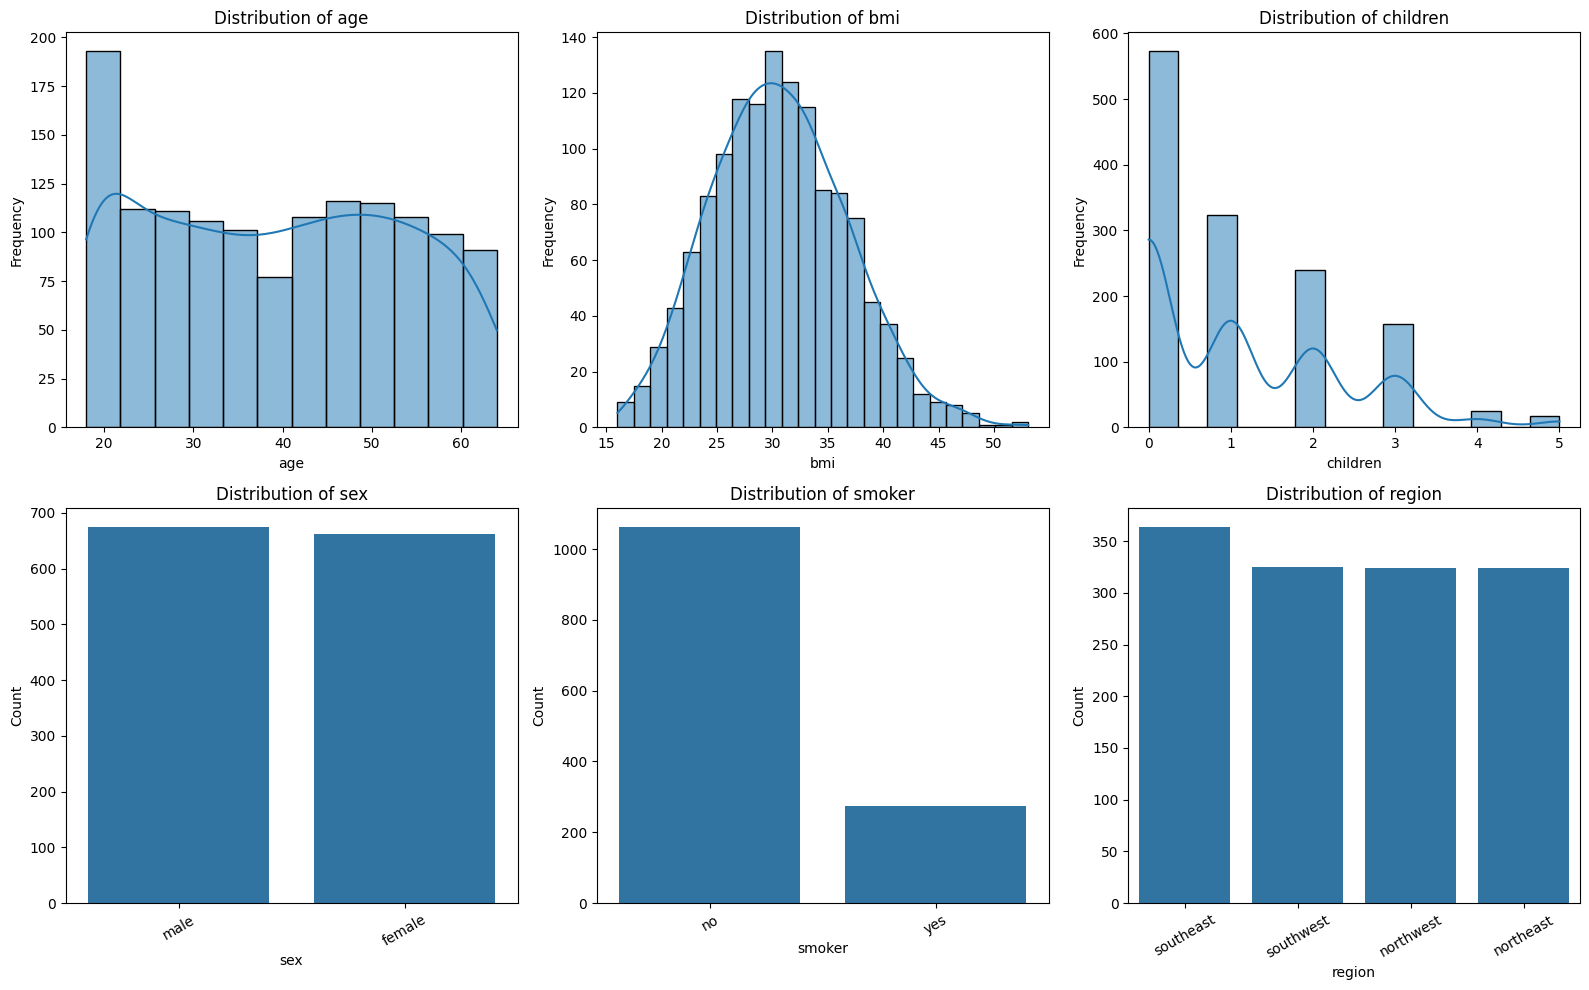

In [25]:
# Feature Distribution: numeric + categorical features together

target_col = 'expenses'

numeric_features = df.drop(columns=[target_col]).select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.drop(columns=[target_col]).select_dtypes(include=['object', 'category', 'string']).columns.tolist()

all_features = numeric_features + categorical_features

plt.figure(figsize=(16, 10))

for i, col in enumerate(all_features):
    plt.subplot(2, 3, i + 1)
    
    if col in numeric_features:
        sns.histplot(df[col], kde=True)
        plt.ylabel('Frequency')
    else:
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.ylabel('Count')
        plt.xticks(rotation=30)
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

### Target Distribution

Target Variable Distribution


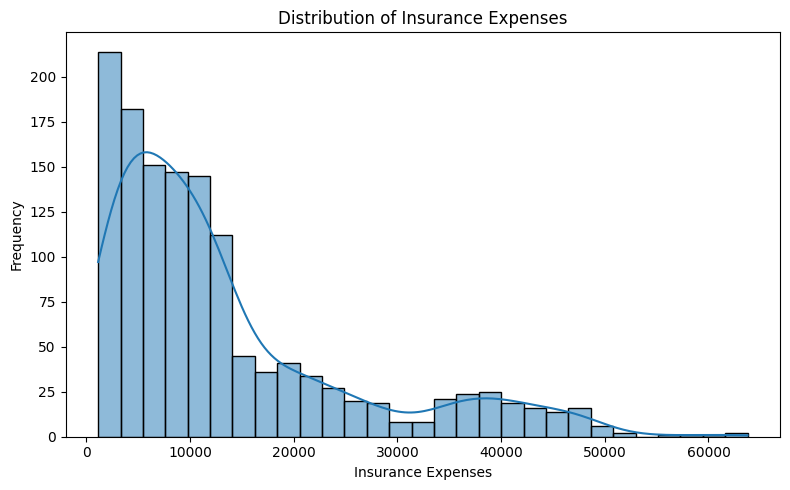

In [23]:
print("Target Variable Distribution")

plt.figure(figsize=(8, 5))

sns.histplot(df['expenses'], kde=True)

plt.title('Distribution of Insurance Expenses')
plt.xlabel('Insurance Expenses')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

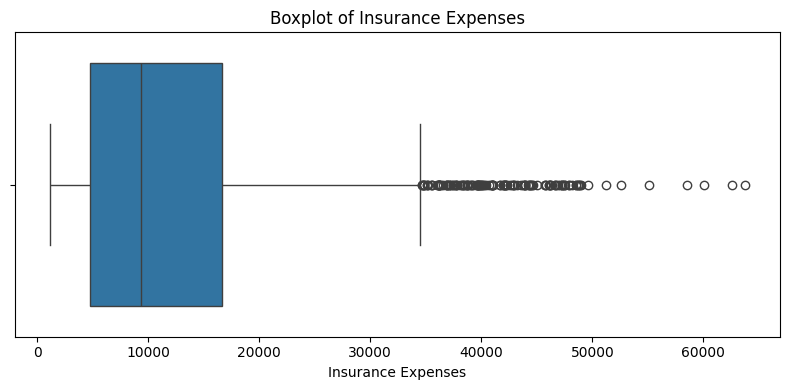

In [24]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['expenses'])

plt.title('Boxplot of Insurance Expenses')
plt.xlabel('Insurance Expenses')

plt.tight_layout()
plt.show()

### Correlation Analysis

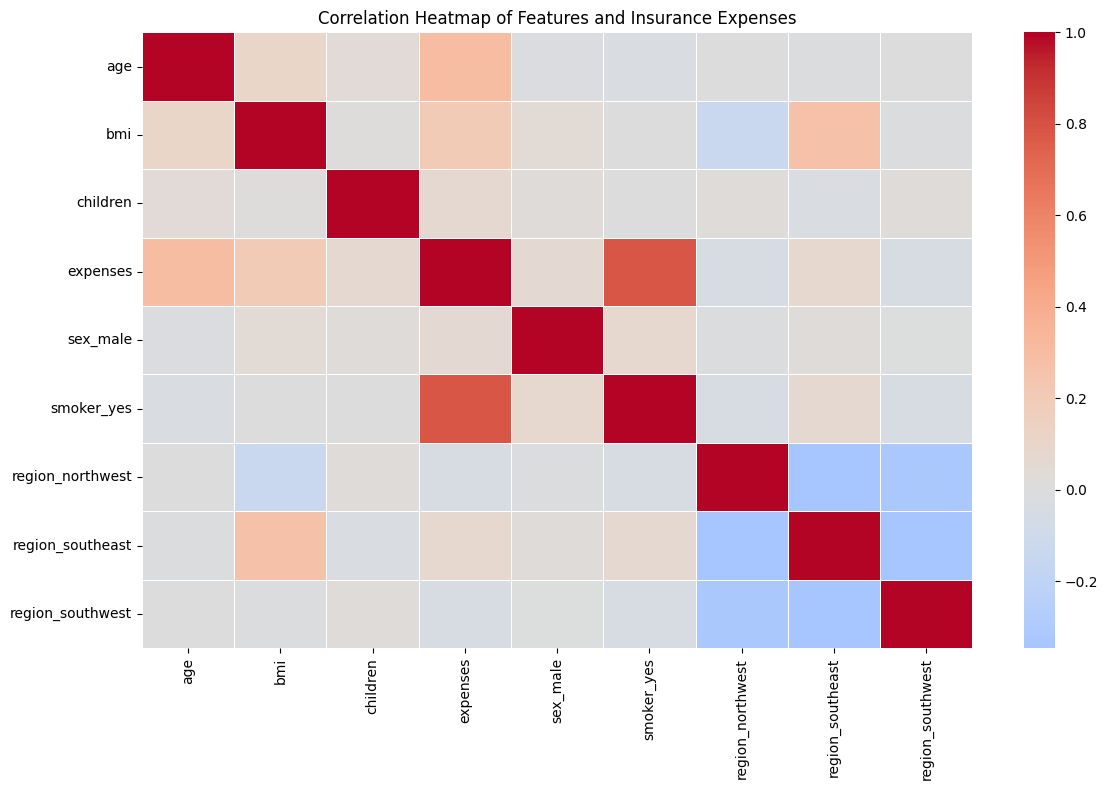

Correlation with Insurance Expenses:
expenses            1.000000
smoker_yes          0.787234
age                 0.298308
bmi                 0.198637
region_southeast    0.073578
children            0.067389
sex_male            0.058045
region_northwest   -0.038695
region_southwest   -0.043637
Name: expenses, dtype: float64


In [28]:
# Correlation Analysis using One-Hot Encoding

# Create a copy so the original dataset is not changed
corr_df = df.copy()

# One-hot encode categorical/string features for correlation analysis
corr_encoded_df = pd.get_dummies(
    corr_df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

# Calculate correlation matrix
corr_matrix = corr_encoded_df.corr()

# Plot heatmap without annotations
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Features and Insurance Expenses')
plt.tight_layout()
plt.show()

# Show correlation of each feature with the target variable
target_corr = corr_matrix['expenses'].sort_values(ascending=False)

print("Correlation with Insurance Expenses:")
print(target_corr)

### Pairwise Analysis 

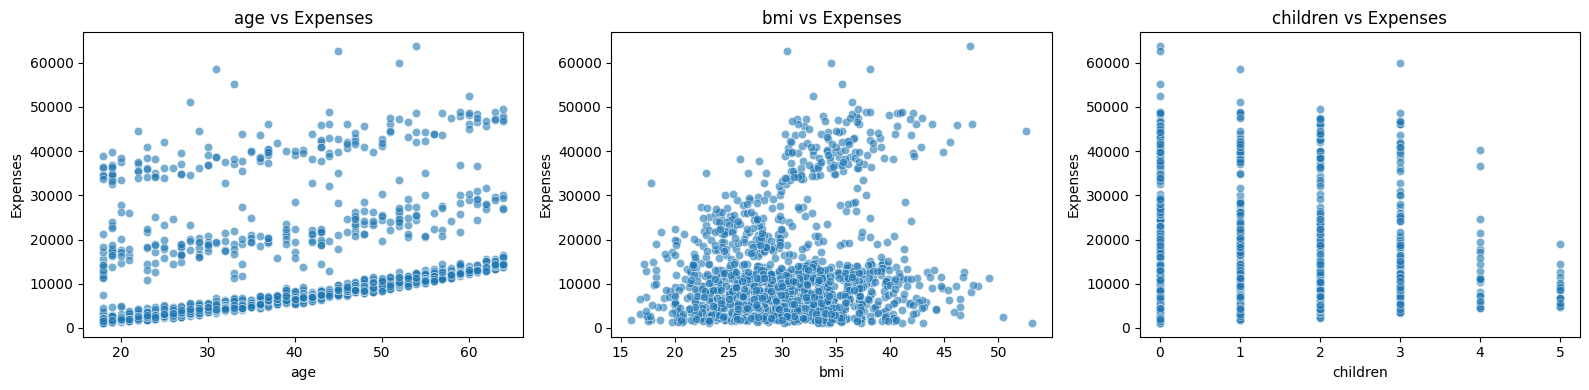

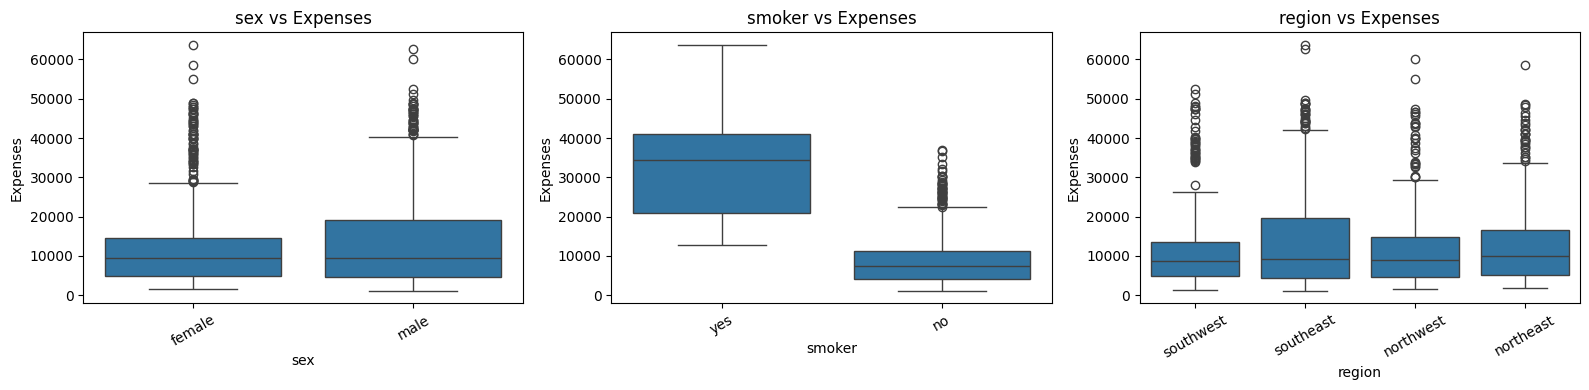

In [29]:
# Pairwise analysis against target variable: expenses

target_col = 'expenses'

numeric_features = df.drop(columns=[target_col]).select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.drop(columns=[target_col]).select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# Numerical features vs expenses
plt.figure(figsize=(16, 4))

for i, col in enumerate(numeric_features):
    plt.subplot(1, len(numeric_features), i + 1)
    sns.scatterplot(data=df, x=col, y=target_col, alpha=0.6)
    plt.title(f'{col} vs Expenses')
    plt.xlabel(col)
    plt.ylabel('Expenses')

plt.tight_layout()
plt.show()


# Categorical features vs expenses
plt.figure(figsize=(16, 4))

for i, col in enumerate(categorical_features):
    plt.subplot(1, len(categorical_features), i + 1)
    sns.boxplot(data=df, x=col, y=target_col)
    plt.title(f'{col} vs Expenses')
    plt.xlabel(col)
    plt.ylabel('Expenses')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Data Splitting

## Feature Engineering

## Model Development

## Model Evaluation

## Recommended Model